## Step 1: Install and Import Required Libraries

We use the following libraries:
- `requests`: To fetch webpage content
- `BeautifulSoup`: To parse and extract HTML data
- `TextBlob` and `VADER`: For performing sentiment analysis
- `pandas`: To organize and display our results

---

## Step 2: Scraping the Wikipedia Page

We use `requests` to fetch the "Back to the Future" Wikipedia page and `BeautifulSoup` to parse it. We specifically target sections like Title, Introduction, History, and Plot.

---

## Step 3: Extracting Section Content

We define a function that finds specific sections on the page (e.g., “History”, “Plot”) and gathers all text until the next section header.

---

## Step 4: Sentiment Analysis

We apply two tools:
- **TextBlob**: Measures polarity (positive/negative) and subjectivity
- **VADER**: Breaks sentiment down into positivity, negativity, neutrality, and a compound score.

---

## Step 5: Results & Visualization

We compile the sentiment scores into a Pandas DataFrame, then visualize the polarity and compound scores in a bar chart.


In [43]:
!pip install requests beautifulsoup4 nltk textblob vaderSentiment


In [44]:
import requests
from bs4 import BeautifulSoup
from textblob import TextBlob
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import nltk


In [45]:
url = "https://en.wikipedia.org/wiki/Back_to_the_Future"
response = requests.get(url)
soup = BeautifulSoup(response.content, 'html.parser')


In [46]:
def get_section_text(header_name):
    section = soup.find('span', {'id': header_name})
    if section:
        content = []
        for sibling in section.parent.find_next_siblings():
            if sibling.name == 'h2':
                break
            if sibling.name == 'p':
                content.append(sibling.get_text())
        return "\n".join(content)
    return "Section not found."

title = soup.find('h1').text
intro_paragraph = soup.find('p').text
history_text = get_section_text("History")
main_content_text = get_section_text("Features")  
references = [ref.text for ref in soup.find_all('cite')[:5]]  

intro_paragraph = ''
for p in soup.find_all('p'):
    if p.text.strip():
        intro_paragraph = p.text
        break
        
main_content_text = get_section_text("Plot")



In [47]:
analyzer = SentimentIntensityAnalyzer()

def analyze_sentiment(text):
    blob = TextBlob(text)
    vader = analyzer.polarity_scores(text)
    return {
        "TextBlob Polarity": blob.sentiment.polarity,
        "TextBlob Subjectivity": blob.sentiment.subjectivity,
        "VADER Compound": vader['compound'],
        "VADER Positivity": vader['pos'],
        "VADER Negativity": vader['neg'],
        "VADER Neutral": vader['neu']
    }

sections = {
    "Title": title,
    "Introductory Paragraph": intro_paragraph,
    "History": history_text,
    "Main Content": main_content_text,
    "References": " ".join(references)
}

results = {section: analyze_sentiment(text) for section, text in sections.items()}


In [48]:
import pandas as pd
df = pd.DataFrame(results).T
df


,TextBlob Polarity,TextBlob Subjectivity,VADER Compound,VADER Positivity,VADER Negativity,VADER Neutral
Title,0.000000,0.062500,0.0000,0.000,0.000,1.000
Introductory Paragraph,0.072727,0.243182,-0.1779,0.080,0.095,0.825
History,0.000000,0.000000,0.0000,0.000,0.000,1.000
Main Content,0.000000,0.000000,0.0000,0.000,0.000,1.000
References,0.158965,0.387753,0.8805,0.095,0.016,0.890


,TextBlob Polarity,TextBlob Subjectivity,VADER Compound,VADER Positivity,VADER Negativity,VADER Neutral
Title,0.000000,0.062500,0.000000,0.000000,0.000000,1.000000
Introductory Paragraph,0.072727,0.243182,-0.177900,0.080000,0.095000,0.825000
History,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
Main Content,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
References,0.158965,0.387753,0.880500,0.095000,0.016000,0.890000


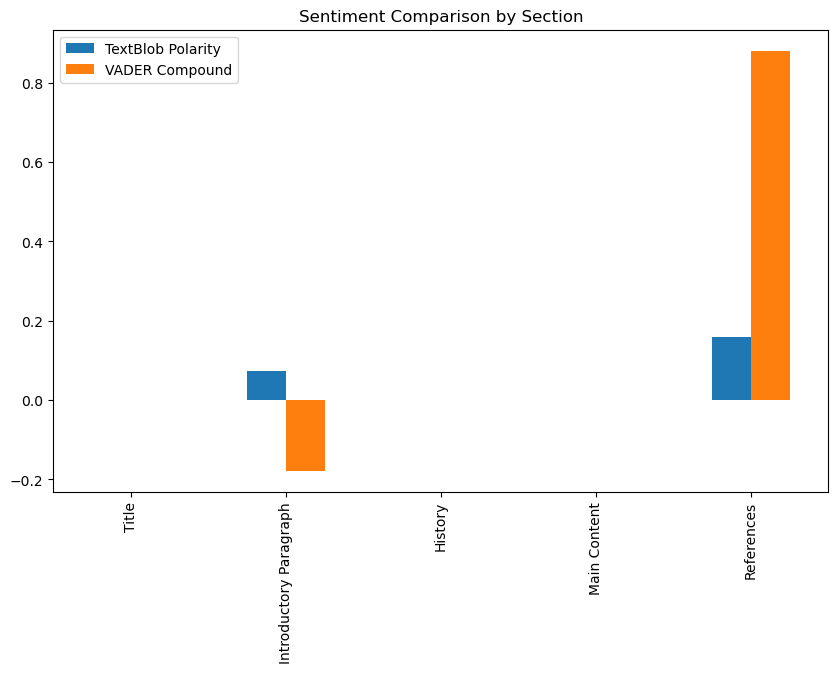

In [49]:
df[['TextBlob Polarity', 'VADER Compound']].plot(kind='bar', title='Sentiment Comparison by Section', figsize=(10,6))
df.style.background_gradient(cmap='RdYlGn')
